In [2]:
%cd ~/cdv
import os

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

import rho_plus as rp

is_dark = False
theme, cs = rp.mpl_setup(is_dark)
rp.plotly_setup(is_dark)

/home/nmiklaucic/cdv


In [3]:
from pymatgen.core import Structure

s = Structure.from_file('data/087.cif')
s

Structure Summary
Lattice
    abc : 3.46566108 5.912730870000001 5.45788908
 angles : 89.99986914 89.99991061 90.01299071999999
 volume : 111.84044720244309
      A : 3.465661079995782 0.0 5.406950504201276e-06
      B : -0.0013405984239926575 5.912730718007075 1.35043098847761e-05
      C : 0.0 0.0 5.45788908
    pbc : True True True
PeriodicSite: Mn0 (Mn) (1.731, 4.91, 2.721) [0.4999, 0.8303, 0.4985]
PeriodicSite: Mn1 (Mn) (1.733, 1.003, 5.45) [0.5001, 0.1697, 0.9985]
PeriodicSite: Mn2 (Mn) (3.465, 1.953, 2.72) [0.9998, 0.3304, 0.4984]
PeriodicSite: Mn3 (Mn) (-0.0003616, 3.959, 5.449) [0.0001547, 0.6696, 0.9984]
PeriodicSite: O4 (O) (-0.0002849, 1.977, 0.6282) [4.711e-05, 0.3343, 0.1151]
PeriodicSite: O5 (O) (1.732, 4.933, 0.6285) [0.5001, 0.8342, 0.1151]
PeriodicSite: O6 (O) (1.732, 0.9801, 3.357) [0.4999, 0.1658, 0.6151]
PeriodicSite: O7 (O) (3.465, 3.936, 3.357) [1.0, 0.6657, 0.6151]

In [4]:
from mace.calculators import mace_mp
from ase import build
from pathlib import Path

atoms = s.to_ase_atoms()

calc = mace_mp(dispersion=False, default_dtype="float32", device='cpu', model='medium')
calc.calculate(atoms=atoms)
calc.results

/home/nmiklaucic/miniconda3/envs/baysic/lib/python3.10/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/nmiklaucic/miniconda3/envs/baysic/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/nmiklaucic/miniconda3/envs/baysic/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using Materials Project MACE for MACECalculator with /home/nmiklaucic/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Default dtype float32 does not match model dtype float64, converting models to float32.


/home/nmiklaucic/miniconda3/envs/baysic/lib/python3.10/site-packages/mace/calculators/mace.py:139: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


{'energy': -62.19428253173828,
 'free_energy': -62.19428253173828,
 'node_energy': array([ 0.6044607 ,  0.6044612 ,  0.6045575 ,  0.6045661 , -0.5645795 ,
        -0.5625615 , -0.5624423 , -0.56454134], dtype=float32),
 'forces': array([[ 0.00144889, -0.00834819, -0.02244547],
        [-0.00140253,  0.00836157, -0.0228434 ],
        [ 0.00255957, -0.01262425, -0.01770079],
        [-0.00251168,  0.01247615, -0.01785059],
        [ 0.00115938, -0.02385711,  0.02021094],
        [ 0.00214564, -0.02360006,  0.02019669],
        [-0.00219745,  0.02361456,  0.02025911],
        [-0.00120165,  0.02397709,  0.0201733 ]], dtype=float32),
 'stress': array([-1.71648376e-02, -2.06205640e-02, -1.71729904e-02, -5.20058961e-07,
         6.87242164e-07, -8.41139627e-05])}

In [5]:
calc.results['free_energy'] / atoms.get_number_of_atoms()

/tmp/ipykernel_1115050/260399794.py:1: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  calc.results['free_energy'] / atoms.get_number_of_atoms()


-7.774285316467285

In [6]:
# ckpt_params = dict(seven_calc.model.named_parameters())
# ckpt_params = {k: v.detach().cpu().numpy() for k, v in ckpt_params.items()}
# np.save('precomputed/sevennet_ckpt.npy', ckpt_params)

In [7]:
from functools import partial
from copy import deepcopy


def serialize_atomgraph(data):    
    return data


class Recorder:    
    def __init__(self):
        self.inputs = {}
        self.outputs = {}

    def pre_hook(self, mod, args, name='module'):        
        self.inputs[name] = serialize_atomgraph(args)

    def post_hook(self, mod, args, output, name='module'):        
        self.outputs[name] = serialize_atomgraph(output)


rec = Recorder()
atoms = s.to_ase_atoms()
handles = []
for name, mod in calc.models[0].named_modules():
    try:
        handle = mod.register_forward_hook(partial(rec.post_hook, name=name))
        handles.append(handle)
        handle = mod.register_forward_pre_hook(partial(rec.pre_hook, name=name))
        handles.append(handle)
    except RuntimeError:
        continue

try:
    calc.calculate(atoms=atoms)
finally:
    for handle in handles:
        handle.remove()
print(calc.results['energy'] / s.num_sites)
len(rec.inputs)

-7.774285316467285


64

In [8]:
rec.inputs.keys()

dict_keys(['atomic_energies_fn', '', 'node_embedding', 'node_embedding.linear', 'spherical_harmonics', 'radial_embedding', 'radial_embedding.cutoff_fn', 'radial_embedding.bessel_fn', 'interactions.0', 'interactions.0.skip_tp', 'interactions.0.linear_up', 'interactions.0.conv_tp_weights', 'interactions.0.conv_tp_weights.layer0', 'interactions.0.conv_tp_weights.layer0.act', 'interactions.0.conv_tp_weights.layer1', 'interactions.0.conv_tp_weights.layer2', 'interactions.0.conv_tp_weights.layer3', 'interactions.0.conv_tp', 'interactions.0.linear', 'interactions.0.reshape', 'products.0', 'products.0.symmetric_contractions', 'products.0.symmetric_contractions.contractions.0', 'products.0.symmetric_contractions.contractions.0.graph_opt_main', 'products.0.symmetric_contractions.contractions.0.contractions_weighting.0', 'products.0.symmetric_contractions.contractions.0.contractions_features.0', 'products.0.symmetric_contractions.contractions.0.contractions_weighting.1', 'products.0.symmetric_con

In [9]:
y_filter = rec.outputs['interactions.0.conv_tp_weights'].numpy(force=True)
y_filter.shape

(536, 512)

In [10]:
b_filter = rec.inputs['interactions.0.conv_tp_weights'][0].numpy(force=True)
b_filter.shape

(536, 10)

In [11]:
x_filter = rec.inputs['radial_embedding'][0].numpy(force=True)
x_filter.shape

(536, 1)

In [12]:
mace = calc.models[0]
def mace_radial(x):
    b = mace.radial_embedding(x.reshape(-1, 1), None, None, None)
    mlp = mace.interactions[0].conv_tp_weights
    return b, mlp(b)

mace_radial(torch.tensor([[0.1]]))[1].shape

NameError: name 'torch' is not defined

In [13]:
import torch
x_filter = torch.linspace(2, 6, 512)
b_filter, y_filter = mace_radial(x_filter)

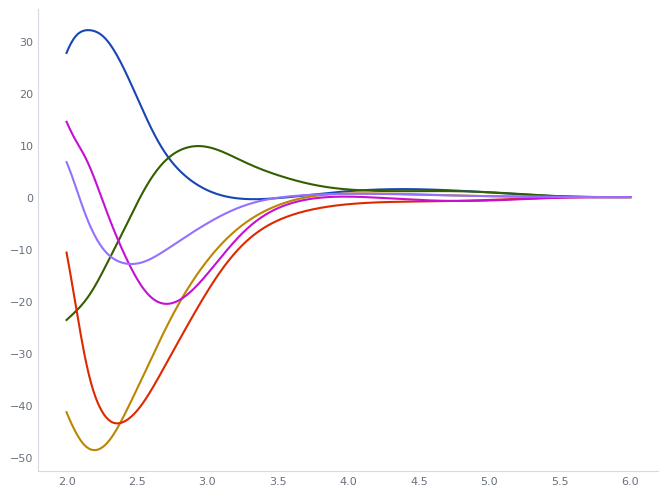

In [14]:
inds = np.random.default_rng(32).choice(y_filter.shape[-1], size=6, replace=False)

xx = x_filter.numpy(force=True).reshape(-1)
yy = y_filter.numpy(force=True)

plt.plot(xx, yy[:, inds])

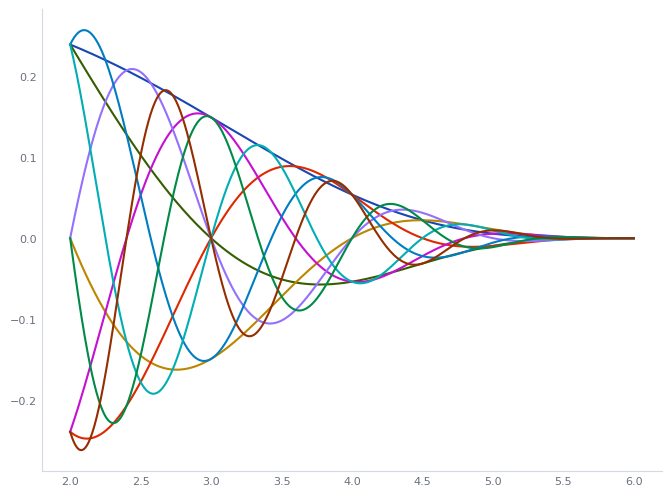

In [15]:
bb = b_filter.numpy(force=True)
plt.plot(xx, bb)

In [16]:
ww, resid, rank, s = np.linalg.lstsq(bb, yy)
yy_hat = bb @ ww
ww.shape

/tmp/ipykernel_1115050/139730463.py:1: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  ww, resid, rank, s = np.linalg.lstsq(bb, yy)


(10, 512)

In [17]:
explained_var = resid / (np.var(yy) + 1e-4)
explained_var.argmax()

196

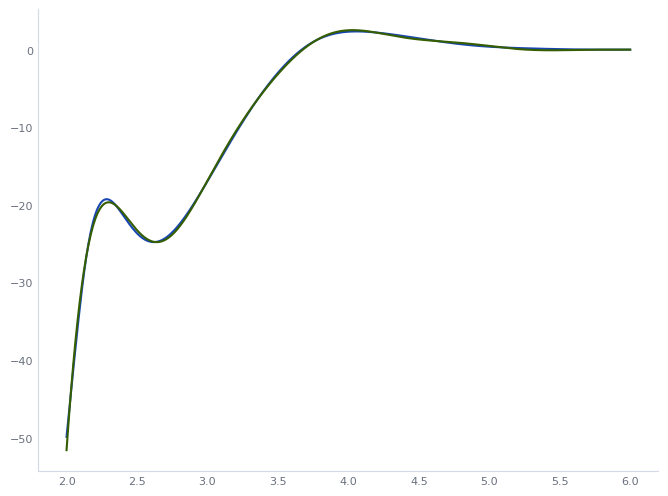

In [100]:
plt.plot(xx, yy[:, 196])
plt.plot(xx, yy_hat[:, 196])

In [99]:
mace.interactions[1].conv_tp_weights

FullyConnectedNet[10, 64, 64, 64, 1280]

In [41]:
import torch
from torch import nn

trimmed_calc = mace_mp(dispersion=False, default_dtype="float32", device='cpu', model='medium')
trimmed_mace = trimmed_calc.models[0]

for interaction in trimmed_mace.interactions:
    y_filter = interaction.conv_tp_weights(b_filter)
    ww, resid, rank, s = torch.linalg.lstsq(b_filter, y_filter)
    conv_tp_filter = nn.Linear(*ww.shape, bias=False)
    conv_tp_filter.state_dict()['weight'][...] = ww.T
    interaction.conv_tp_weights = conv_tp_filter

Using Materials Project MACE for MACECalculator with /home/nmiklaucic/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Default dtype float32 does not match model dtype float64, converting models to float32.


/home/nmiklaucic/miniconda3/envs/baysic/lib/python3.10/site-packages/mace/calculators/mace.py:139: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


In [50]:
trimmed_size = sum(param.numel() for param in trimmed_mace.parameters())
trimmed_size

4574224

In [42]:
trimmed_calc.calculate(atoms=atoms)
print(trimmed_calc.results['energy'] / len(atoms))

-7.773669719696045


In [43]:
calc = mace_mp(dispersion=False, default_dtype="float32", device='cpu', model='medium')
calc.calculate(atoms=atoms)
print(calc.results['energy'] / len(atoms))

Using Materials Project MACE for MACECalculator with /home/nmiklaucic/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Default dtype float32 does not match model dtype float64, converting models to float32.
-7.774285316467285


/home/nmiklaucic/miniconda3/envs/baysic/lib/python3.10/site-packages/mace/calculators/mace.py:139: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


In [51]:
sum(param.numel() for param in mace.parameters())

4688656

In [78]:
for name, v in trimmed_mace.named_parameters():
    print(f'{name:>100}\t{v.numel():>12_}\t{" ".join(map(lambda s: f"{s:>10}", v.shape)):>50}')

                                                                        node_embedding.linear.weight	      11_392	                                             11392
                                                                     interactions.0.linear_up.weight	      16_384	                                             16384
                                                               interactions.0.conv_tp_weights.weight	       5_120	                                    512         10
                                                                        interactions.0.linear.weight	      65_536	                                             65536
                                                                       interactions.0.skip_tp.weight	   1_458_176	                                           1458176
                                                                     interactions.1.linear_up.weight	      32_768	                                             32768
          

In [77]:
for name, v in mace.named_parameters():
    print(f'{name:>100}\t{v.numel():>12_}\t{" ".join(map(lambda s: f"{s:>10}", v.shape)):>50}')

                                                                        node_embedding.linear.weight	      11_392	                                             11392
                                                                     interactions.0.linear_up.weight	      16_384	                                             16384
                                                        interactions.0.conv_tp_weights.layer0.weight	         640	                                     10         64
                                                        interactions.0.conv_tp_weights.layer1.weight	       4_096	                                     64         64
                                                        interactions.0.conv_tp_weights.layer2.weight	       4_096	                                     64         64
                                                        interactions.0.conv_tp_weights.layer3.weight	      32_768	                                     64        512
          

In [104]:
128 * 128 * 89

1458176

In [81]:
P = []
P_names = []
for name, param in mace.named_parameters():
    if param.shape[0] == 89 and param.shape[-1] == 128:
        P_names.append(name)
        P.append(param)

P = torch.cat(P, dim=1)
P.shape

torch.Size([89, 114, 128])

In [89]:
u, s, vh = torch.linalg.svd(P.reshape(89, -1), full_matrices=False)

In [90]:
u.shape, s.shape, vh.shape

(torch.Size([89, 89]), torch.Size([89]), torch.Size([89, 14592]))

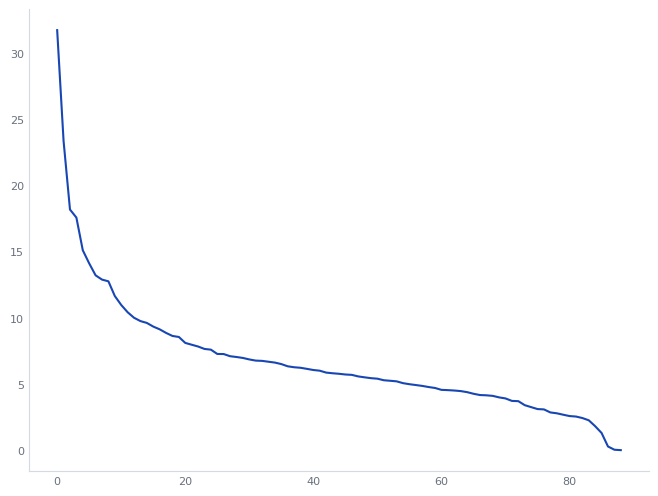

In [ ]:
plt.plot(s.cumsum(s))

In [103]:
nc = 40

P_hat = u[:, :nc] @ torch.diag_embed(s[:nc]) @ vh[:nc, :]

(1 - torch.dist(P, P_hat.reshape(P.shape)) / torch.dist(P, torch.zeros_like(P)))

tensor(0.6133)

In [ ]:
x = rec.inputs['0_self_connection_intro.linear'].numpy(force=True)
x

In [ ]:
params = dict(seven_calc.model.get_submodule('0_self_connection_intro.linear').named_parameters())
w = params['weight'].numpy(force=True).reshape(128, 224)
w

In [ ]:
((x / np.sqrt(128)) @ w)[0, 0]

In [ ]:
rec.outputs['reduce_hidden_to_energy.linear']

In [ ]:
ag = rec.outputs['']

In [ ]:
i = np.where((ag['edge_index'][0] == 48) & (ag['edge_index'][1] == 0))[0].item()
i

In [ ]:
rec.outputs['edge_embedding']['edge_embedding'][i]

In [ ]:
rec.inputs['0_self_connection_intro']['x']

In [ ]:
rec.outputs['0_self_connection_intro.linear'][0, 1].item()

In [ ]:
sns.heatmap(rec.outputs['onehot_to_feature_x']['x'], robust=True, center=0)

In [ ]:
params = dict(seven_calc.model.onehot_to_feature_x.named_parameters())
w = params['linear.weight'].detach().cpu().numpy()
sns.heatmap(w.reshape(89, 128)[[11]], center=0, robust=True)

In [ ]:
seven_calc.model

In [ ]:
rec.outputs['edge_embedding.spherical.sph'][i][6].item()

In [ ]:
sns.heatmap(rec.outputs['onehot_to_feature_x'][0]['x'], robust=True)

In [ ]:
rec.outputs['onehot_to_feature_x.linear'][0][0].item()

In [ ]:
{k: getattr(v, 'shape', v) for k, v in rec.outputs['onehot_to_feature_x.linear'][0].items()}